# Part 1: Cancellation Prediction (RQ1)

In [1]:
import pandas as pd
import numpy as np
from utils import load_hotel_data, DATA_DIR, OUTPUT_DIR

RANDOM_STATE = 316
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
%matplotlib inline

## Step 1: Load dataset and define target

Load the cleaned Hotel Booking Demand dataset and define the target variable `is_canceled`

In [2]:
# Load dataset
df = load_hotel_data()

# Define target
TARGET = "is_canceled"
y = df[TARGET]

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Step 2: Remove leakage variables and unusable columns

Drop columns that would leak the outcome or are not available at prediction time:

- **reservation_status**, **reservation_status_date** — directly encode cancellation outcome
- **assigned_room_type** — assigned at check-in, after the cancellation decision
- **agent**, **company** — many missing; spec says remove entirely
- **booking_changes** — occurs after initial booking; we predict at booking time
- **Target (is_canceled)** — removed from features; we keep it separately as `y`

In [3]:
# Columns to exclude
EXCLUDE_COLS = [
    "reservation_status",
    "reservation_status_date",
    "assigned_room_type",
    "agent",
    "company",
    "booking_changes",
    TARGET,
]
exclude = [c for c in EXCLUDE_COLS if c in df.columns]
df_clean = df.drop(columns=exclude)

print("Dropped columns:", exclude)
print("Shape:", df_clean.shape)
df_clean.head(2)

Dropped columns: ['reservation_status', 'reservation_status_date', 'assigned_room_type', 'agent', 'company', 'booking_changes', 'is_canceled']
Shape: (119390, 25)


,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,342,2015,July,27,1,0,0,2,0.0,...,0,0,0,C,No Deposit,0,Transient,0.0,0,0
1,Resort Hotel,737,2015,July,27,1,0,0,2,0.0,...,0,0,0,C,No Deposit,0,Transient,0.0,0,0


## Step 3: Handle missing values

Apply imputation
- **children** — fill with 0 (no children is a valid booking state; check frequency first)

In [5]:
# children: NaN -> 0
if "children" in df_clean.columns:
    n_missing = df_clean["children"].isna().sum()
    if n_missing > 0:
        df_clean["children"] = df_clean["children"].fillna(0).astype(int)
        print(f"children: filled {n_missing} missing with 0")
    else:
        print("children: no missing values")

print(df_clean.isna().sum().sum())

children: no missing values
488


## Step 4: Define candidate feature pool

Use a domain-informed set of candidate features (booking characteristics, customer attributes, reservation details, temporal info). Restrict country to top-k levels and group the rest as "Other" to avoid instability from too many categories.

In [6]:
CANDIDATE_FEATURES = [
    "lead_time",
    "arrival_date_year",
    "arrival_date_month",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "reserved_room_type",
    "deposit_type",
    "days_in_waiting_list",
    "customer_type",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
]
if "hotel" in df_clean.columns and "hotel" not in CANDIDATE_FEATURES:
    CANDIDATE_FEATURES = ["hotel"] + CANDIDATE_FEATURES

# Keep only columns that exist in df_clean
CANDIDATE_FEATURES = [c for c in CANDIDATE_FEATURES if c in df_clean.columns]
print("Candidate features:", len(CANDIDATE_FEATURES))
print(CANDIDATE_FEATURES)

Candidate features: 25
['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'deposit_type', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


In [8]:
# Country: keep top-k most frequent, group rest as "Other"
TOP_COUNTRY_K = 15
if "country" in df_clean.columns:
    top_countries = df_clean["country"].value_counts().head(TOP_COUNTRY_K).index.tolist()
    df_clean["country"] = df_clean["country"].where(
        df_clean["country"].isin(top_countries), "Other"
    )

## Step 5: Split into train/test sets

Use a stratified 80/20 split so that the cancellation rate is similar in train and test. Store indices so we can later attach predictions to the correct rows.

In [9]:
from sklearn.model_selection import train_test_split

# Features and target (y from original df; same index as df_clean)
X_full = df_clean[CANDIDATE_FEATURES].copy()
y_full = df[TARGET].values

# Stratified split; keep indices for final prediction table
train_ix, test_ix = train_test_split(
    np.arange(len(y_full)),
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_full,
)
X_train = X_full.iloc[train_ix]
X_test = X_full.iloc[test_ix]
y_train = y_full[train_ix]
y_test = y_full[test_ix]

print("Train size:", len(y_train), "| Test size:", len(y_test))
print("Cancel rate — train: {:.3%} | test: {:.3%}".format(y_train.mean(), y_test.mean()))

Train size: 95512 | Test size: 23878
Cancel rate — train: 37.041% | test: 37.042%


## Step 6: Build preprocessing pipeline

Use ColumnTransformer: scale numeric features and one-hot encode categoricals (drop first category to avoid redundancy).

In [10]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Numeric vs categorical (from candidate set in X_train)
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
print("Numeric:", num_cols)
print("Categorical:", cat_cols)

preprocessor = ColumnTransformer(
    [
        ("num", StandardScaler(), num_cols),
        (
            "cat",
            OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
            cat_cols,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)
preprocessor.fit(X_train)

# Feature names after transform (for feature importance / reporting)
feature_names_out = (
    num_cols
    + preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols).tolist()
)
print("Encoded feature count:", len(feature_names_out))

Numeric: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Categorical: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type']
Encoded feature count: 71


## Step 7: Train reference model and compute feature importance

Train a **Random Forest** on the encoded features. Use its **feature importance** to rank variables; the next step will keep the top 10–15 for all candidate models.

In [11]:
from sklearn.ensemble import RandomForestClassifier

# Encode train and test with the fitted preprocessor
X_train_enc = preprocessor.transform(X_train)
X_test_enc = preprocessor.transform(X_test)

# Reference model: Random Forest
ref_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
ref_model.fit(X_train_enc, y_train)

# Feature importance (for selecting top features in Step 8)
imp = pd.DataFrame({
    "Feature": feature_names_out,
    "Importance": ref_model.feature_importances_,
}).sort_values("Importance", ascending=False)

print("Top 20 features by importance:")
imp.head(20)

Top 20 features by importance:


,Feature,Importance
0,lead_time,0.130297
66,deposit_type_Non Refund,0.100243
13,adr,0.084826
44,country_PRT,0.073402
15,total_of_special_requests,0.059547
3,arrival_date_day_of_month,0.058258
2,arrival_date_week_number,0.051994
5,stays_in_week_nights,0.039444
10,previous_cancellations,0.032029
4,stays_in_weekend_nights,0.026184


## Step 8: Select final feature subset

Keep the **top 10–15 features** by importance from the reference model. All candidate models in the next steps will use this same subset so comparison is fair.

In [14]:
# Keep top 12 features (balance between predictive power and interpretability)
N_TOP_FEATURES = 12
imp_top = imp.head(N_TOP_FEATURES)
SELECTED_FEATURE_NAMES = imp_top["Feature"].tolist()

# Indices of these features in the encoded array
selected_ix = [feature_names_out.index(f) for f in SELECTED_FEATURE_NAMES]

# Subset encoded data for all downstream models
X_train_sel = X_train_enc[:, selected_ix]
X_test_sel = X_test_enc[:, selected_ix]

print("Selected features (top {} by importance):".format(N_TOP_FEATURES))
display(imp_top)
print("X_train_sel shape:", X_train_sel.shape, "| X_test_sel shape:", X_test_sel.shape)

Selected features (top 12 by importance):


,Feature,Importance
0,lead_time,0.130297
66,deposit_type_Non Refund,0.100243
13,adr,0.084826
44,country_PRT,0.073402
15,total_of_special_requests,0.059547
3,arrival_date_day_of_month,0.058258
2,arrival_date_week_number,0.051994
5,stays_in_week_nights,0.039444
10,previous_cancellations,0.032029
4,stays_in_weekend_nights,0.026184


X_train_sel shape: (95512, 12) | X_test_sel shape: (23878, 12)


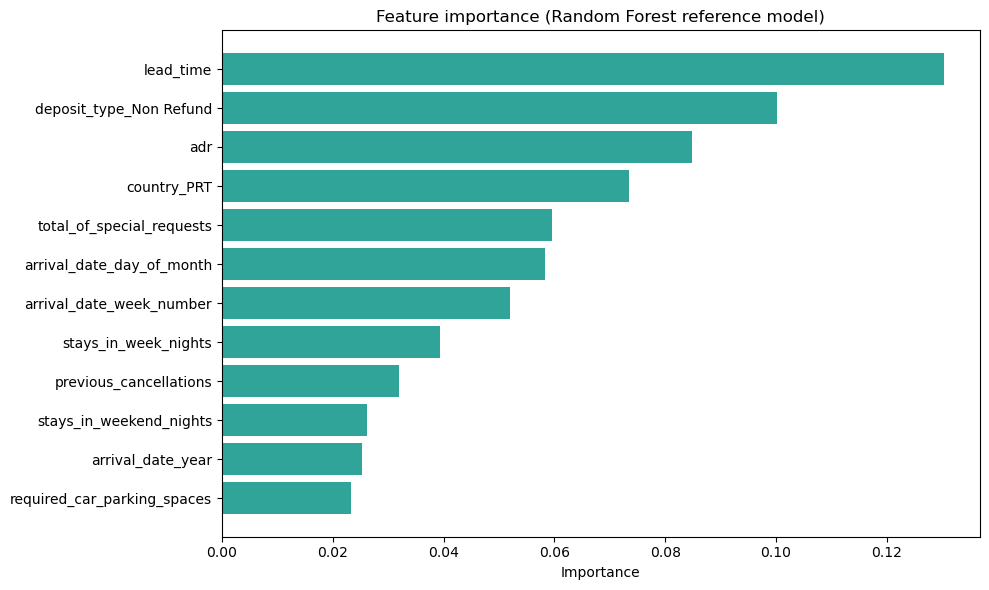

Saved: /Users/leoleung/5533-proj/outputs/fig_feature_importance.png


In [24]:
# Figure 5: Feature importance ranking (for report)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
imp_plot = imp_top.sort_values("Importance", ascending=True)
ax.barh(imp_plot["Feature"].astype(str), imp_plot["Importance"], color="#0d9488", alpha=0.85)
ax.set_xlabel("Importance")
ax.set_title("Feature importance (Random Forest reference model)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", OUTPUT_DIR / "fig_feature_importance.png")

**Table 2: Selected features and description** (for report)

In [28]:
# Short description for selected features (base names; one-hot use category)
feature_descriptions = {
    "lead_time": "Days between booking and arrival",
    "arrival_date_year": "Year of arrival",
    "arrival_date_month": "Month of arrival",
    "arrival_date_week_number": "Week number of arrival",
    "arrival_date_day_of_month": "Day of month of arrival",
    "stays_in_weekend_nights": "Number of weekend nights",
    "stays_in_week_nights": "Number of week nights",
    "adults": "Number of adults",
    "children": "Number of children",
    "babies": "Number of babies",
    "adr": "Average daily rate",
    "required_car_parking_spaces": "Required car parking spaces",
    "total_of_special_requests": "Number of special requests",
    "previous_cancellations": "Previous cancellations by customer",
    "previous_bookings_not_canceled": "Previous bookings not canceled",
    "days_in_waiting_list": "Days in waiting list",
    "is_repeated_guest": "Is repeated guest (0/1)",
    "hotel": "Hotel type (Resort / City)",
    "meal": "Meal type",
    "country": "Country (top-k + Other)",
    "market_segment": "Market segment",
    "distribution_channel": "Distribution channel",
    "reserved_room_type": "Reserved room type",
    "deposit_type": "Deposit type",
    "customer_type": "Customer type",
}

def describe_feature(fname):
    for key, desc in feature_descriptions.items():
        if fname == key or fname.startswith(key + "_"):
            return desc if fname == key else "{} (one-hot)".format(key)
    return "Encoded feature"

table2 = pd.DataFrame({
    "Feature": SELECTED_FEATURE_NAMES,
    "Description": [describe_feature(f) for f in SELECTED_FEATURE_NAMES],
})
table2.to_csv(OUTPUT_DIR / "table2_selected_features.csv", index=False)
display(table2)
print("Saved:", OUTPUT_DIR / "table2_selected_features.csv")

,Feature,Description
0,lead_time,Days between booking and arrival
1,deposit_type_Non Refund,deposit_type (one-hot)
2,adr,Average daily rate
3,country_PRT,country (one-hot)
4,total_of_special_requests,Number of special requests
5,arrival_date_day_of_month,Day of month of arrival
6,arrival_date_week_number,Week number of arrival
7,stays_in_week_nights,Number of week nights
8,previous_cancellations,Previous cancellations by customer
9,stays_in_weekend_nights,Number of weekend nights


Saved: /Users/leoleung/5533-proj/outputs/table2_selected_features.csv


## Step 9: Train all candidate models on the same selected feature set

Train three classifiers on **X_train_sel** / **y_train** (same features for all):

- **Logistic Regression** — interpretable baseline  
- **Random Forest** — non-linear ensemble  
- **HistGradientBoostingClassifier** — sklearn gradient-boosting benchmark  
- **XGBoost** — gradient-boosting benchmark

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
}
trained = {}
for name, clf in models.items():
    clf.fit(X_train_sel, y_train)
    trained[name] = clf
    print("Fitted:", name)

Fitted: Logistic Regression
Fitted: Random Forest
Fitted: HistGradientBoosting
Fitted: XGBoost


## Step 10: Evaluate all models using AUC, F1, and Brier Score

Evaluate each candidate model on the test set. Report **ROC-AUC**, **Accuracy**, **Precision**, **Recall**, **F1**, and **Brier Score**. AUC and Brier are most important for downstream probability-based optimization.

In [21]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss,
)

def evaluate_model(clf, X_te, y_te, name="Model"):
    proba = clf.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "Model": name,
        "AUC": roc_auc_score(y_te, proba),
        "Accuracy": accuracy_score(y_te, pred),
        "Precision": precision_score(y_te, pred, zero_division=0),
        "Recall": recall_score(y_te, pred, zero_division=0),
        "F1": f1_score(y_te, pred, zero_division=0),
        "Brier Score": brier_score_loss(y_te, proba),
    }

results = [evaluate_model(clf, X_test_sel, y_test, name) for name, clf in trained.items()]
model_comparison = pd.DataFrame(results)
model_comparison.round(4)

,Model,AUC,Accuracy,Precision,Recall,F1,Brier Score
0,Logistic Regression,0.8277,0.7775,0.8202,0.5112,0.6299,0.1508
1,Random Forest,0.9382,0.8638,0.8453,0.7740,0.8081,0.0937
2,HistGradientBoosting,0.9063,0.8287,0.8247,0.6825,0.7469,0.1166
3,XGBoost,0.9144,0.8381,0.8292,0.7091,0.7645,0.1113


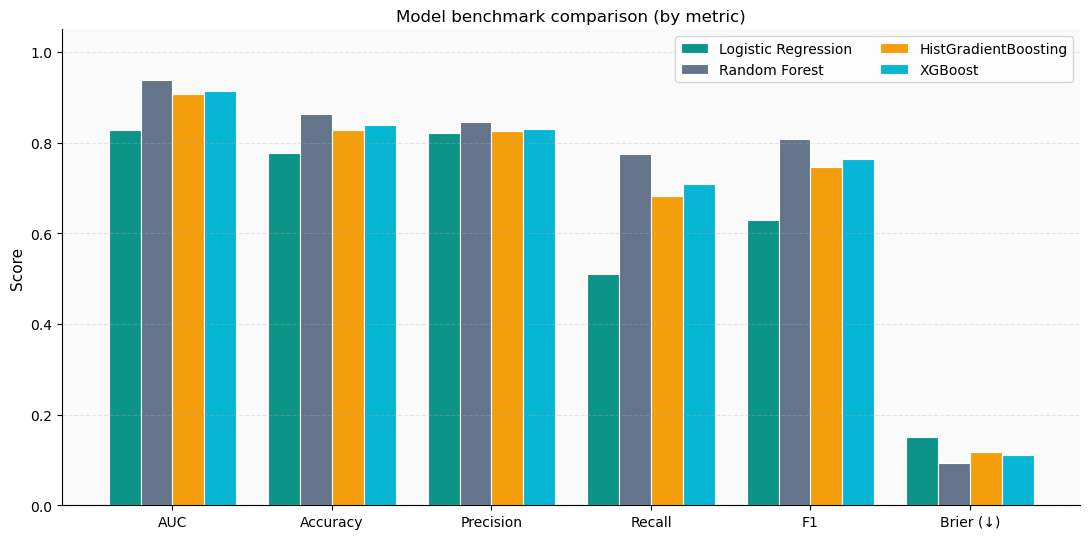

Saved: /Users/leoleung/5533-proj/outputs/fig_model_benchmark.png


In [27]:
# Benchmark figure: compare models by metric (each group = one metric, bars = models)
import matplotlib.pyplot as plt
import numpy as np

# Palette: teal, slate, amber, cyan (distinct and readable)
colors = ["#0d9488", "#64748b", "#f59e0b", "#06b6d4"]
metrics = ["AUC", "Accuracy", "Precision", "Recall", "F1", "Brier Score"]
metric_labels = ["AUC", "Accuracy", "Precision", "Recall", "F1", "Brier (↓)"]
mc = model_comparison.set_index("Model")[metrics]
models = mc.index.tolist()
n_metrics = len(metrics)
n_models = len(models)
x = np.arange(n_metrics)
width = 0.8 / n_models

fig, ax = plt.subplots(figsize=(11, 5.5), facecolor="white")
ax.set_facecolor("#fafafa")
for i, model in enumerate(models):
    offset = (i - n_models / 2) * width + width / 2
    vals = [mc.loc[model, m] for m in metrics]
    c = colors[i % len(colors)]
    ax.bar(x + offset, vals, width, label=model, color=c, edgecolor="white", linewidth=0.8)

ax.set_ylabel("Score", fontsize=11)
ax.set_title("Model benchmark comparison (by metric)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.legend(loc="upper right", ncol=2, frameon=True, fancybox=True, shadow=False)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_model_benchmark.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", OUTPUT_DIR / "fig_model_benchmark.png")

In [22]:
# Final model = best by Brier Score (no calibration)
best_name = model_comparison.loc[model_comparison["Brier Score"].idxmin(), "Model"]
final_model = trained[best_name]
print("Final model:", best_name)

Final model: Random Forest


## Step 13: Export predicted cancellation probabilities for downstream optimization

Build a table with each test-set booking’s **row id**, **actual cancellation**, and **predicted cancellation probability**, plus optional grouping columns. Save to CSV for the overbooking chapter.

In [23]:
# Predict on test set (test_ix from Step 5)
pred_proba_test = final_model.predict_proba(X_test_sel)[:, 1]

out = pd.DataFrame({
    "row_id": test_ix,
    "actual_is_canceled": y_test,
    "predicted_cancel_prob": pred_proba_test,
})
# Add grouping columns for downstream overbooking if available
for col in ["hotel", "arrival_date_year", "arrival_date_month"]:
    if col in df.columns:
        out[col] = df.iloc[test_ix][col].values

# Reorder columns: row_id, grouping, then actual + predicted
group_cols = [c for c in ["hotel", "arrival_date_year", "arrival_date_month"] if c in out.columns]
out = out[["row_id"] + group_cols + ["actual_is_canceled", "predicted_cancel_prob"]]

out.to_csv(OUTPUT_DIR / "predicted_cancellation_probabilities.csv", index=False)
print("Saved:", OUTPUT_DIR / "predicted_cancellation_probabilities.csv")
out.head(10)

Saved: /Users/leoleung/5533-proj/outputs/predicted_cancellation_probabilities.csv


,row_id,hotel,arrival_date_year,arrival_date_month,actual_is_canceled,predicted_cancel_prob
0,68549,City Hotel,2017,May,1,1.000000
1,53135,City Hotel,2016,June,1,1.000000
2,49314,City Hotel,2016,April,1,0.760000
3,58092,City Hotel,2016,October,1,0.507448
4,2799,Resort Hotel,2015,October,1,0.020000
5,86596,City Hotel,2016,April,0,0.030000
6,48301,City Hotel,2016,March,1,1.000000
7,55384,City Hotel,2016,August,1,1.000000
8,107176,City Hotel,2017,March,0,0.430000
9,86833,City Hotel,2016,April,0,0.000000


Save final model and preprocessor for reuse (e.g. Part 2 or scoring new data)

In [29]:
import joblib

# Save model and preprocessor so they can be loaded without retraining
joblib.dump(final_model, OUTPUT_DIR / "final_model.joblib")
joblib.dump(preprocessor, OUTPUT_DIR / "preprocessor.joblib")

# Save selected feature indices and names for applying the same pipeline
import json
with open(OUTPUT_DIR / "selected_features_meta.json", "w") as f:
    json.dump({"selected_ix": selected_ix, "selected_feature_names": SELECTED_FEATURE_NAMES}, f, indent=2)

print("Saved:")
print("  -", OUTPUT_DIR / "final_model.joblib")
print("  -", OUTPUT_DIR / "preprocessor.joblib")
print("  -", OUTPUT_DIR / "selected_features_meta.json")

Saved:
  - /Users/leoleung/5533-proj/outputs/final_model.joblib
  - /Users/leoleung/5533-proj/outputs/preprocessor.joblib
  - /Users/leoleung/5533-proj/outputs/selected_features_meta.json
